In [11]:
import numpy as np # numpy -> numerical operations aur arrays ke liye
import pandas as pd # pandas -> data ko table format me handle karne ke liye
import matplotlib.pyplot as plt # matplotlib -> basic plotting ke liye
import seaborn as sns # seaborn -> advanced statistical visualization ke liye

# Visualization style set kar rahe hain taaki graphs clean dikhe
sns.set_style("whitegrid")

# Default figure size set kar rahe hain (har graph ka size same rahe)
plt.rcParams["figure.figsize"] = (10, 6)

# Reproducibility ke liye random state define kar rahe hain
RANDOM_STATE = 42
print("Environment Ready - Libraries Successfully Imported")

Environment Ready - Libraries Successfully Imported


In [12]:
# ======================================================
# Cell 2: Dataset Load Karna
# ======================================================

# Column names manually define kar rahe hain
# Kyunki dataset me header row nahi hoti
columns = [
    'age',        # Patient ki age
    'sex',        # Gender (1 = male, 0 = female)
    'cp',         # Chest pain type
    'trestbps',   # Resting blood pressure
    'chol',       # Serum cholesterol
    'fbs',        # Fasting blood sugar > 120 mg/dl
    'restecg',    # Resting ECG results
    'thalach',    # Maximum heart rate achieved
    'exang',      # Exercise induced angina
    'oldpeak',    # ST depression induced by exercise
    'slope',      # Slope of peak exercise ST segment
    'ca',         # Number of major vessels colored by fluoroscopy
    'thal',       # Thalassemia type
    'target'      # Heart disease presence (0-4)
]

# CSV file read kar rahe hain
# na_values='?' ka matlab agar dataset me '?' hai to use missing maan lo
df = pd.read_csv(
    '../data/raw/processed.cleveland.data',
    names=columns,
    na_values='?'
)

# Dataset ka shape print kar rahe hain (rows, columns)
print("Dataset Shape:", df.shape)

# First 5 rows dekh rahe hain taaki confirm ho jaye data sahi load hua hai
df.head()

Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [13]:
# ======================================================
# Cell 3: Target Conversion
# ======================================================

# Original target values 0,1,2,3,4 hote hain
# 0 = no disease
# 1-4 = disease present
# Hum binary classification kar rahe hain

df['target'] = (df['target'] > 0).astype(int)

# Ab check karte hain target distribution
print("Target Distribution:")
print(df['target'].value_counts())

Target Distribution:
target
0    164
1    139
Name: count, dtype: int64


In [14]:
# ======================================================
# Cell 4: Dataset Overview
# ======================================================

# info() se pata chalega:
# 1. Total entries
# 2. Data types
# 3. Missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [15]:
# ======================================================
# Cell 5: Missing Values Check
# ======================================================

# Har column me kitne null values hain
missing = df.isnull().sum()

print("Columns With Missing Values:")
print(missing[missing > 0])

# Percentage calculate kar rahe hain
print("\nPercentage of Missing Values:")
print((missing / len(df)) * 100)

Columns With Missing Values:
ca      4
thal    2
dtype: int64

Percentage of Missing Values:
age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.000000
chol        0.000000
fbs         0.000000
restecg     0.000000
thalach     0.000000
exang       0.000000
oldpeak     0.000000
slope       0.000000
ca          1.320132
thal        0.660066
target      0.000000
dtype: float64


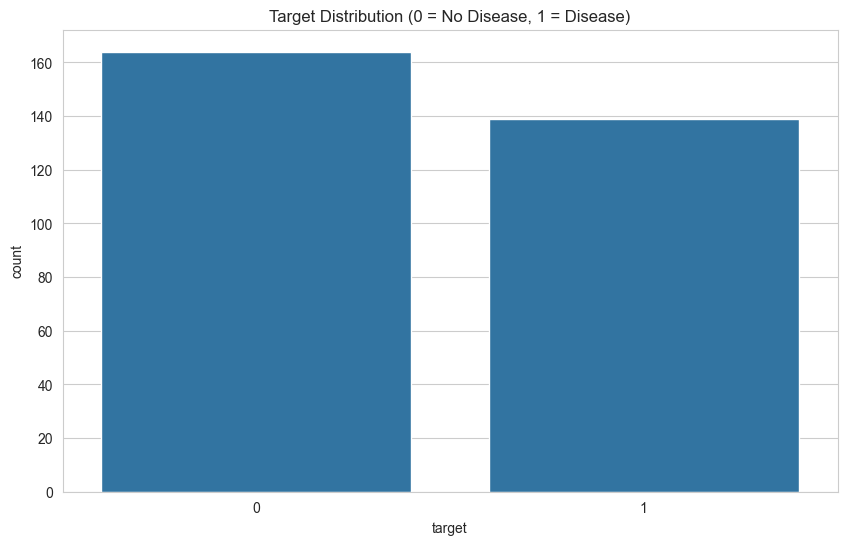

Percentage Distribution:
target
0    54.125413
1    45.874587
Name: proportion, dtype: float64


In [ ]:
# ======================================================
# Cell 6: Target Distribution Visualization
# ======================================================

# Countplot banate hain taaki class balance dikhe
sns.countplot(data=df, x='target')

plt.title("Target Distribution (0 = No Disease, 1 = Disease)")
plt.show()

#1 = Disease Present
#0 = No Disease

# Percentage distribution bhi dekhte hain
print("Percentage Distribution:")
print(df['target'].value_counts(normalize=True) * 100)

In [17]:
# ======================================================
# Cell 7: Missing Values Handle Karna
# ======================================================

# ca column ka median nikal rahe hain
ca_median = df['ca'].median()

# thal column ka median nikal rahe hain
thal_median = df['thal'].median()

# Missing values ko median se fill kar rahe hain
df['ca'].fillna(ca_median, inplace=True)
df['thal'].fillna(thal_median, inplace=True)

# Confirm karte hain ki ab koi missing nahi bacha
print("Missing Values After Imputation:")
print(df.isnull().sum())

Missing Values After Imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_13088\3204443215.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ca'].fillna(ca_median, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_13088\3204443215.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [18]:
# ======================================================
# Cell 8: Numerical Features Define Karna
# ======================================================

# Continuous numerical features
numerical_features = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

print("Numerical Features:")
print(numerical_features)

Numerical Features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


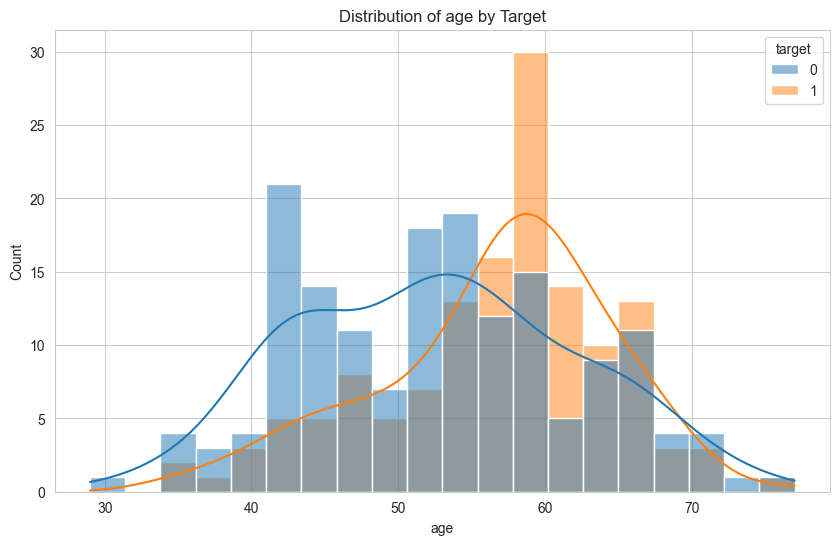

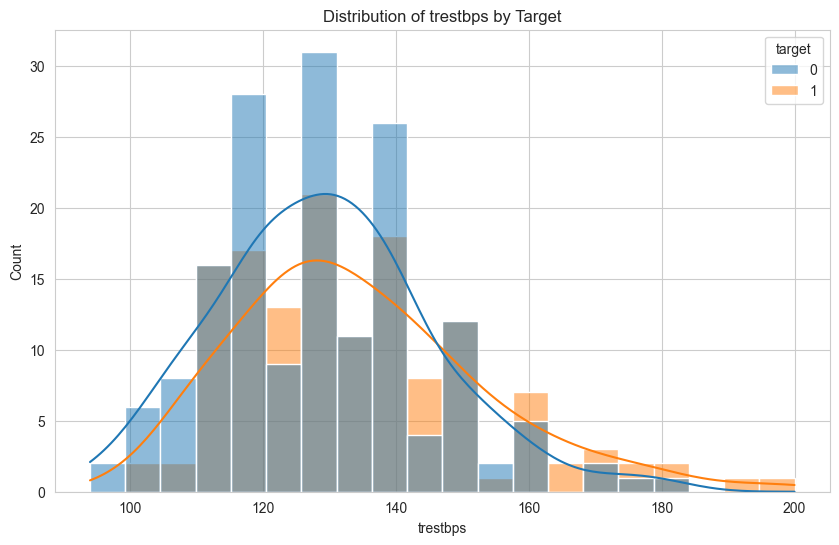

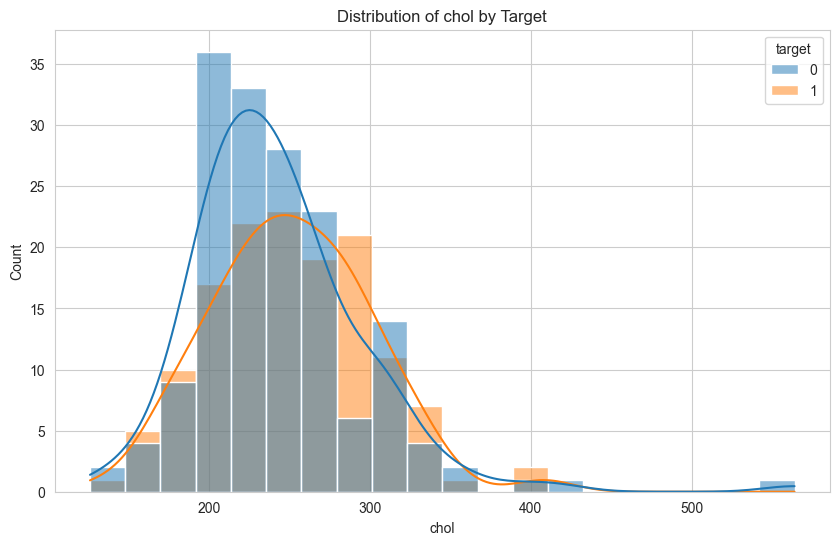

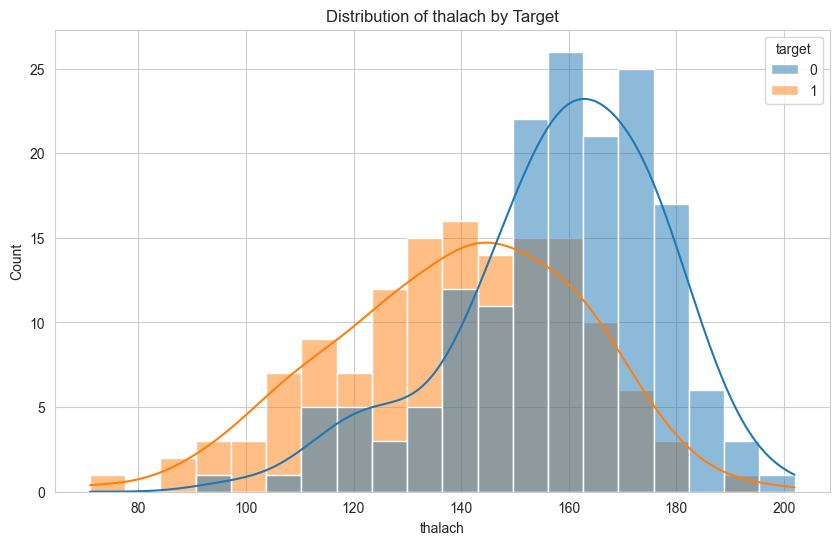

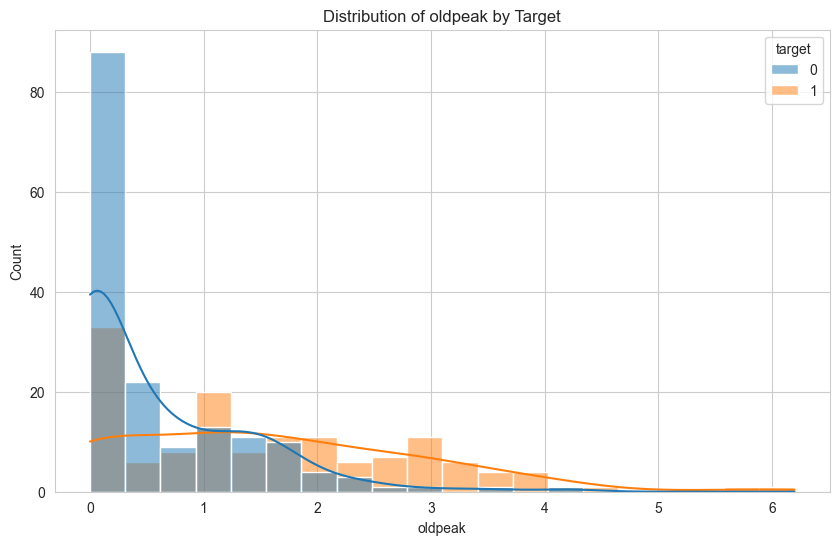

In [19]:
# ======================================================
# Cell 9: Numerical Feature Distribution by Target
# ======================================================

for feature in numerical_features:
    
    plt.figure()
    
    # Disease aur No Disease ke liye distribution compare kar rahe hain
    sns.histplot(
        data=df,
        x=feature,
        hue='target',
        kde=True,
        bins=20
    )
    
    plt.title(f"Distribution of {feature} by Target")
    plt.show()

**Numerical Feature Analysis (Based on Distribution Plots)**
1. Age

Disease group (target = 1) ka distribution slightly right-shifted hai.

55–65 age range me disease cases ka concentration zyada dikhta hai.

Dono classes me noticeable overlap present hai.

Inference:
Age moderately predictive feature lag raha hai. Increasing age ke saath heart disease risk increase ho raha hai, lekin separation strong nahi hai.

**Resting Blood Pressure (trestbps)**

Disease group me higher BP values slightly more frequent hain.

150+ range me disease samples comparatively zyada dikhe.

Significant overlap still present hai.

Inference:
Resting BP weak-to-moderate predictor lag raha hai. Standalone strong separator nahi hai.

**Cholesterol (chol)**

200–300 range me dono classes heavily overlapping hain.

Extreme outliers (>400) present hain.

Clear class separation visible nahi hai.

Inference:
Cholesterol is dataset me strong standalone predictor nahi lag raha. Medical importance hone ke bawajood statistical separation weak hai.

**Maximum Heart Rate Achieved (thalach)**

Clear separation visible hai.

No-disease group higher heart rate (150–180 range) me concentrated hai.

Disease group relatively lower heart rate (110–150 range) me clustered hai.

Inference:
Thalach strong negative predictor lag raha hai. Higher maximum heart rate → lower probability of heart disease.

**ST Depression (oldpeak)**

No-disease group mostly 0 ke around concentrated hai.

Disease group higher oldpeak values (1–4 range) me distributed hai.

Clear distribution shift visible hai.

Inference:
Oldpeak appears to be one of the strongest positive predictors. Higher ST depression → higher disease risk.

**Overall Observations::**

Strongest numerical predictors visually: Oldpeak (Strong Positive Correlation), Thalach (Strong Negative Correlation)

Moderate predictor: Age

Weak-to-moderate: Resting BP

Weak predictor: Cholesterol

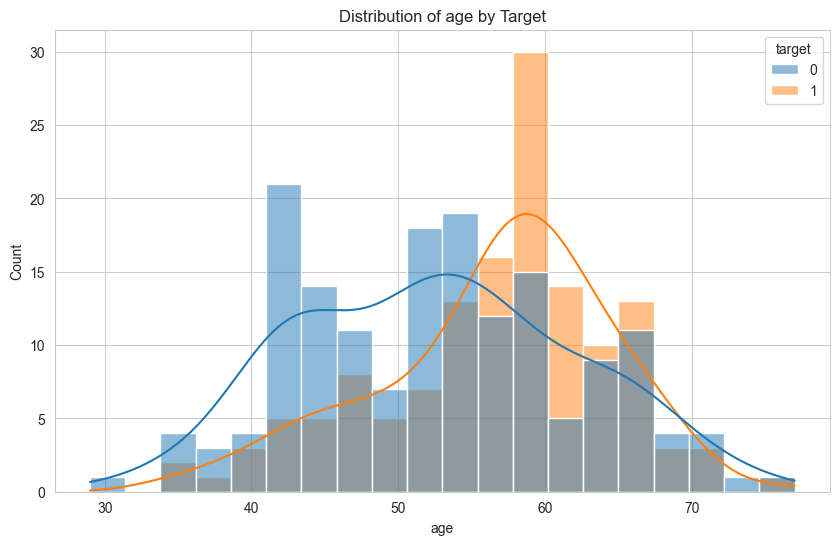

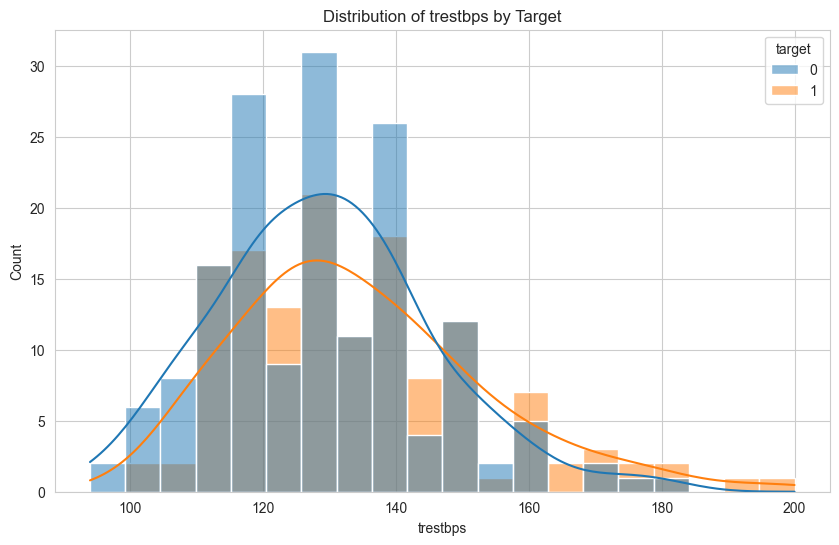

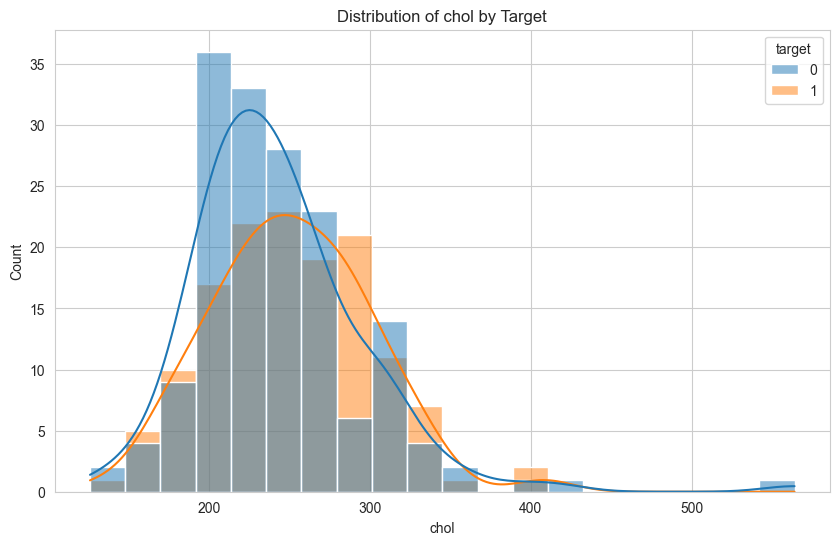

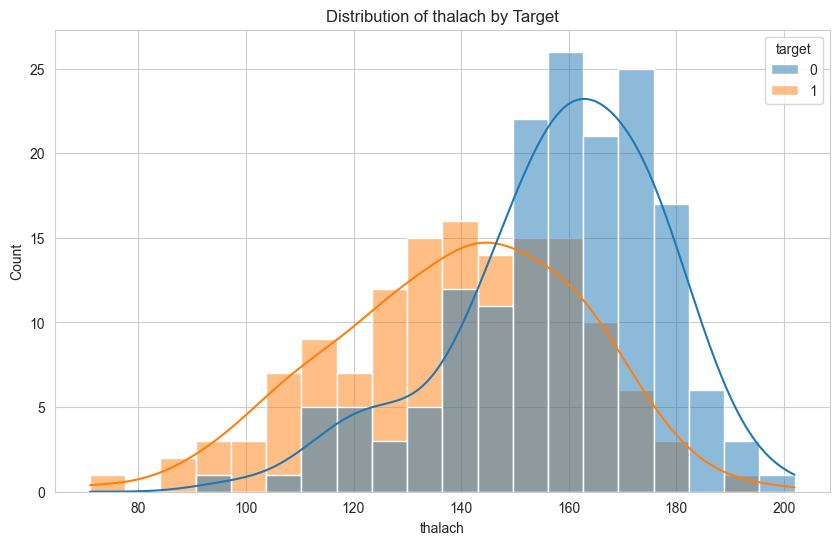

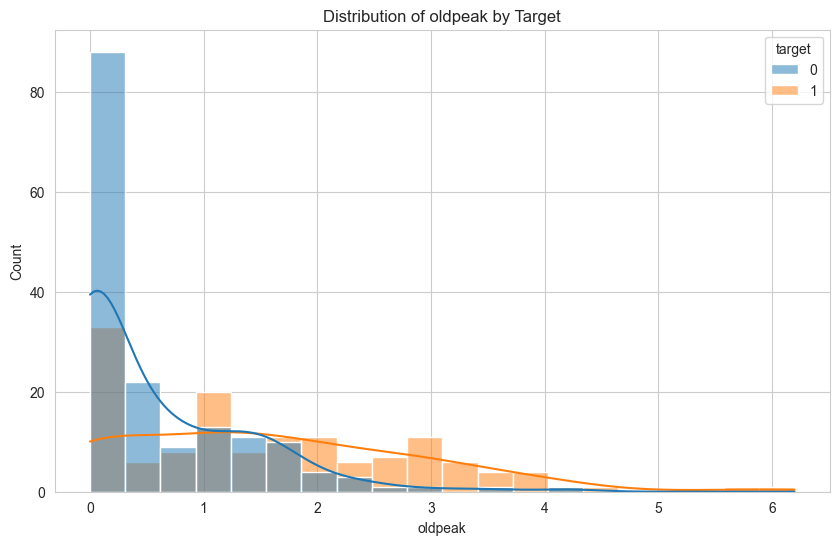

In [20]:
# ======================================================
# Cell 9: Numerical Feature Distribution by Target
# ======================================================

for feature in numerical_features:
    
    plt.figure()
    
    # Disease aur No Disease ke liye distribution compare kar rahe hain
    sns.histplot(
        data=df,
        x=feature,
        hue='target',
        kde=True,
        bins=20
    )
    
    plt.title(f"Distribution of {feature} by Target")
    plt.show()

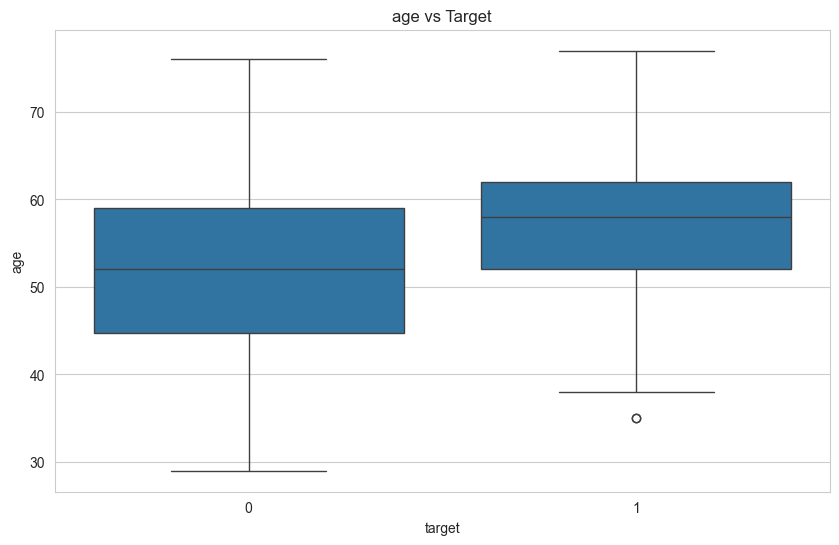

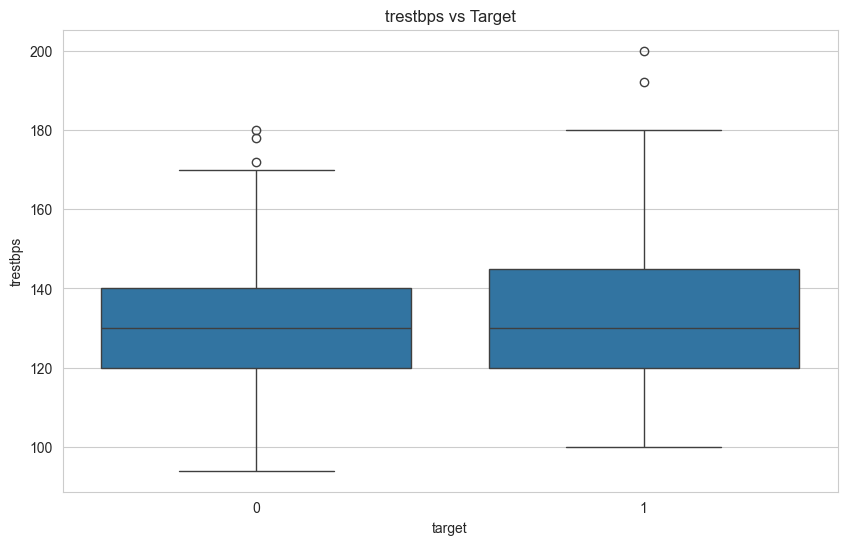

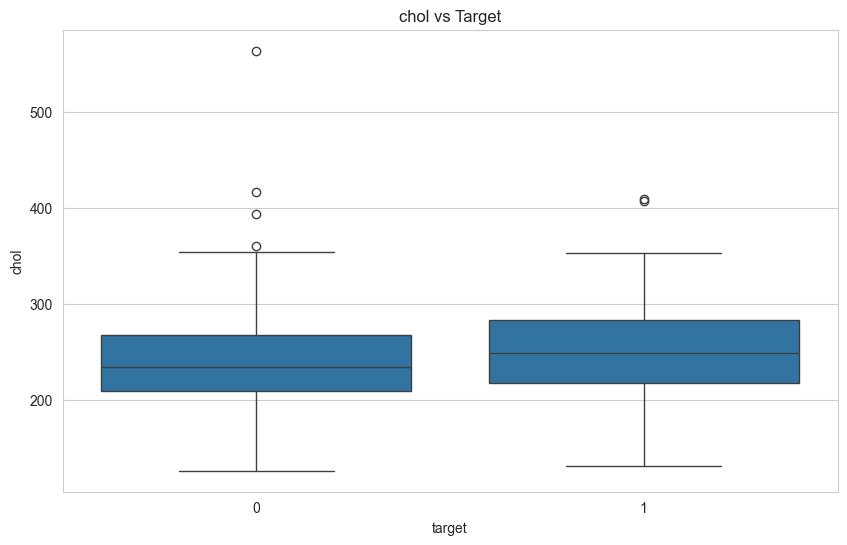

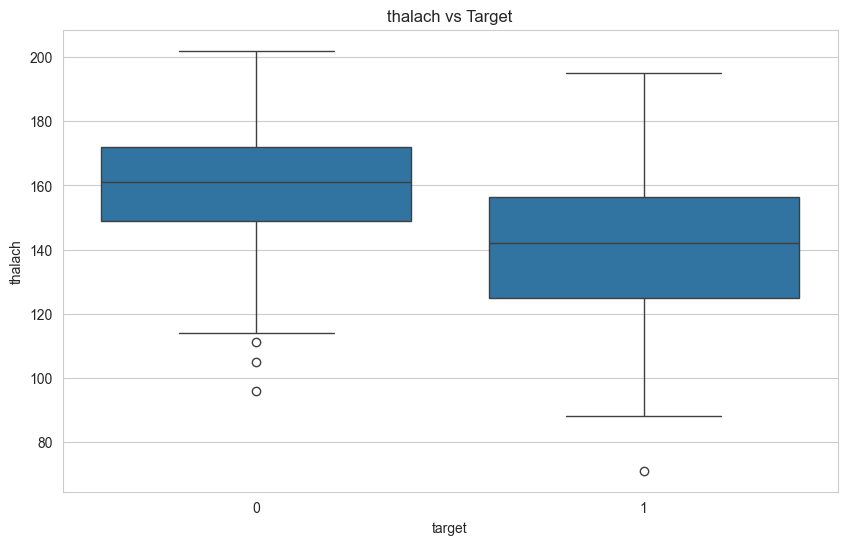

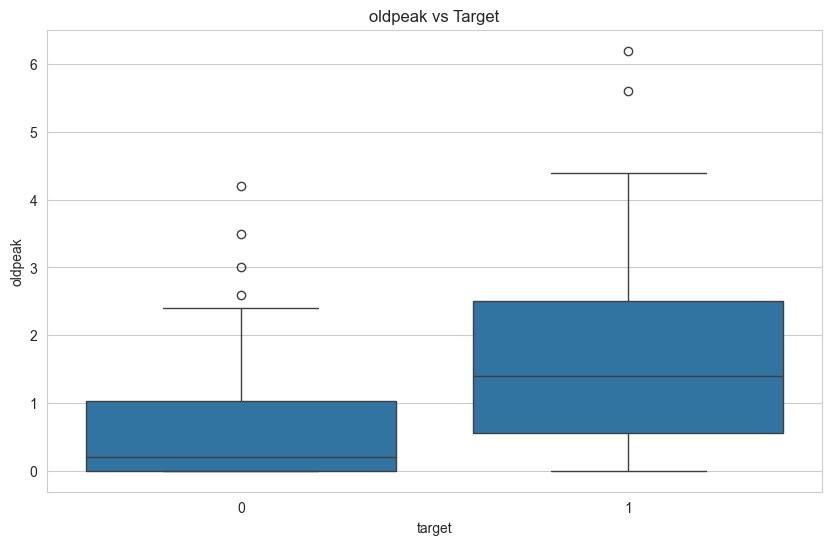

In [21]:
# ======================================================
# Cell 10: Outlier Detection (Boxplot)
# ======================================================

for feature in numerical_features:
    
    plt.figure()
    
    sns.boxplot(
        data=df,
        x='target',
        y=feature
    )
    
    plt.title(f"{feature} vs Target")
    plt.show()

In [22]:
# ======================================================
# Cell 11: Categorical Features Define Karna
# ======================================================

categorical_features = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'ca',
    'thal'
]

print("Categorical Features:")
print(categorical_features)

Categorical Features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


<Figure size 1000x600 with 0 Axes>

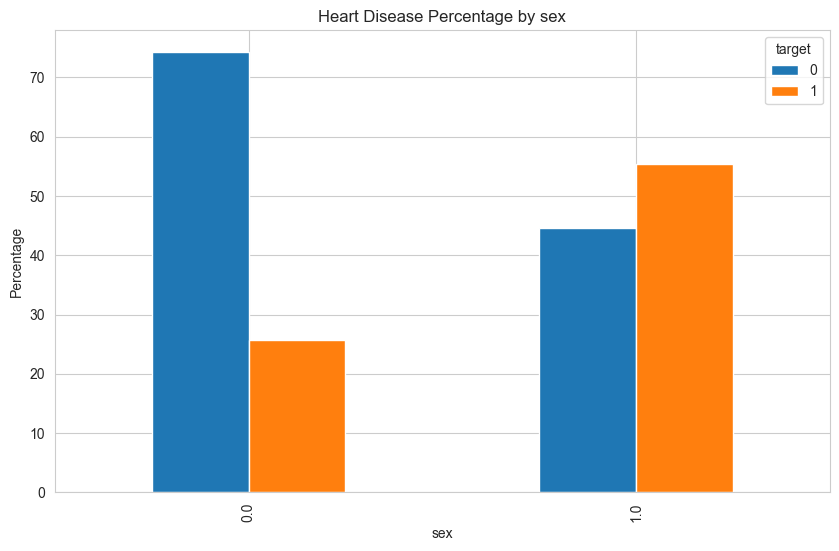

<Figure size 1000x600 with 0 Axes>

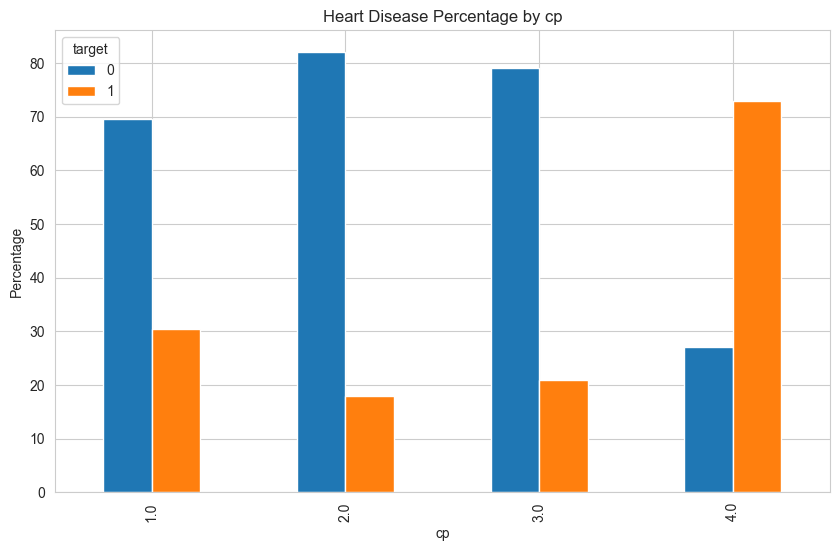

<Figure size 1000x600 with 0 Axes>

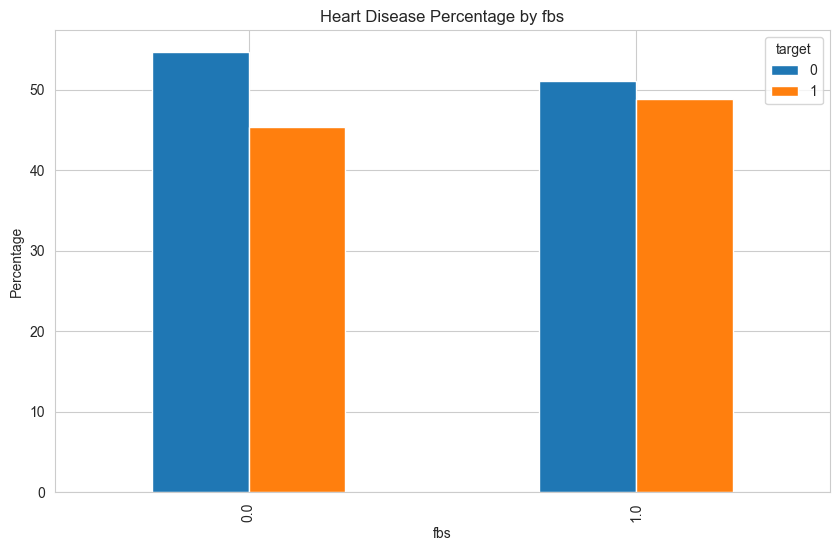

<Figure size 1000x600 with 0 Axes>

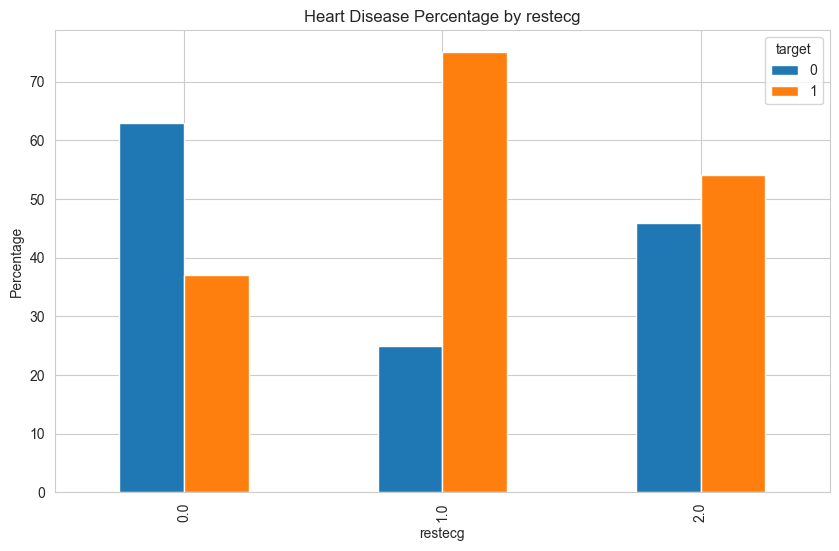

<Figure size 1000x600 with 0 Axes>

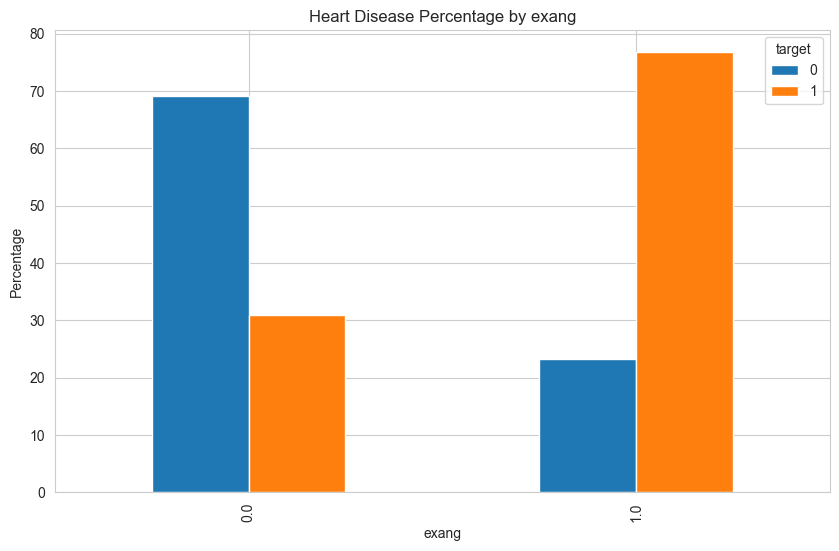

<Figure size 1000x600 with 0 Axes>

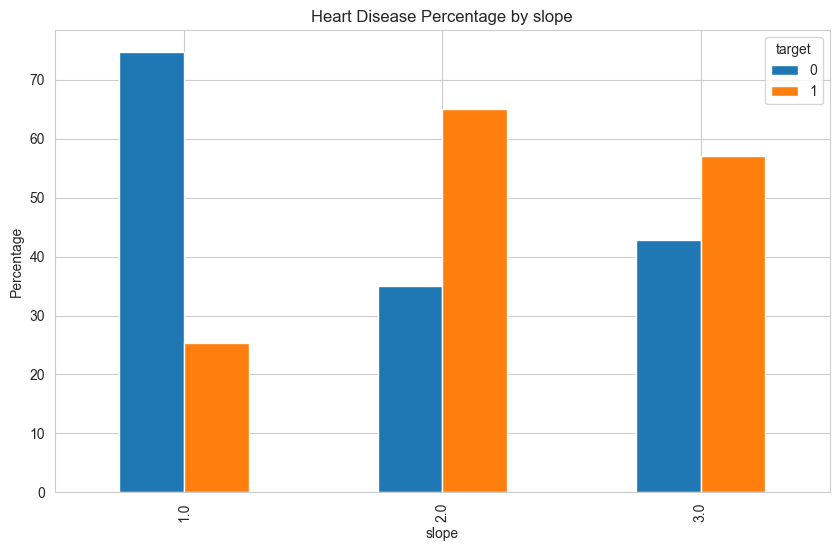

<Figure size 1000x600 with 0 Axes>

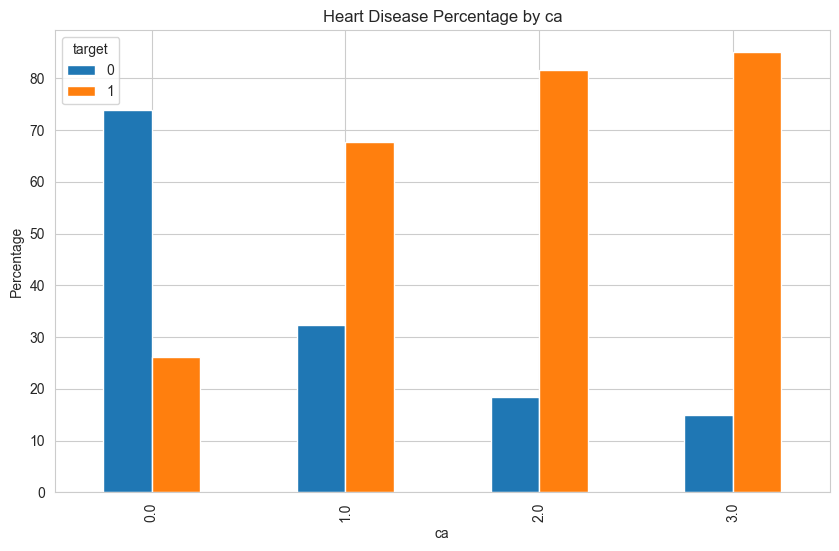

<Figure size 1000x600 with 0 Axes>

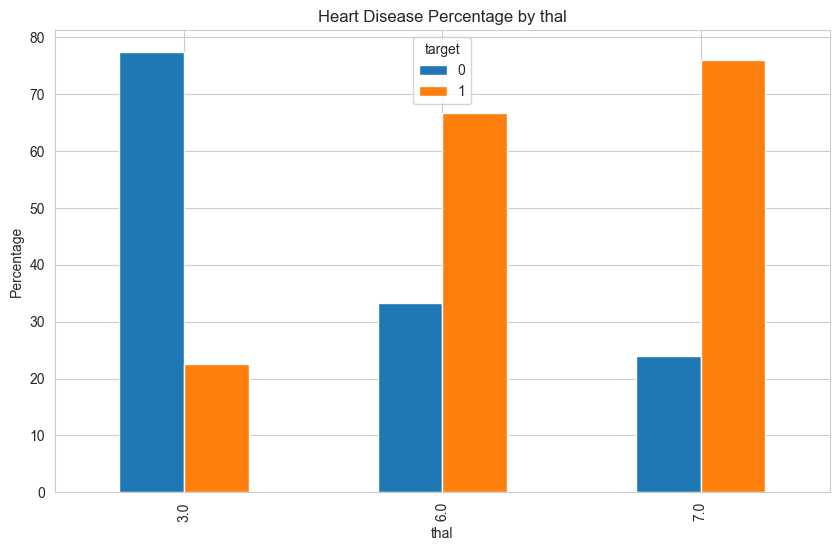

In [24]:
# ======================================================
# Cell 12: Categorical Feature Analysis
# ======================================================

for feature in categorical_features:
    
    plt.figure()
    
    # Crosstab bana rahe hain percentage ke saath
    ct = pd.crosstab(df[feature], df['target'], normalize='index') * 100
    
    ct.plot(kind='bar')
    
    plt.title(f"Heart Disease Percentage by {feature}")
    plt.ylabel("Percentage")
    plt.show()

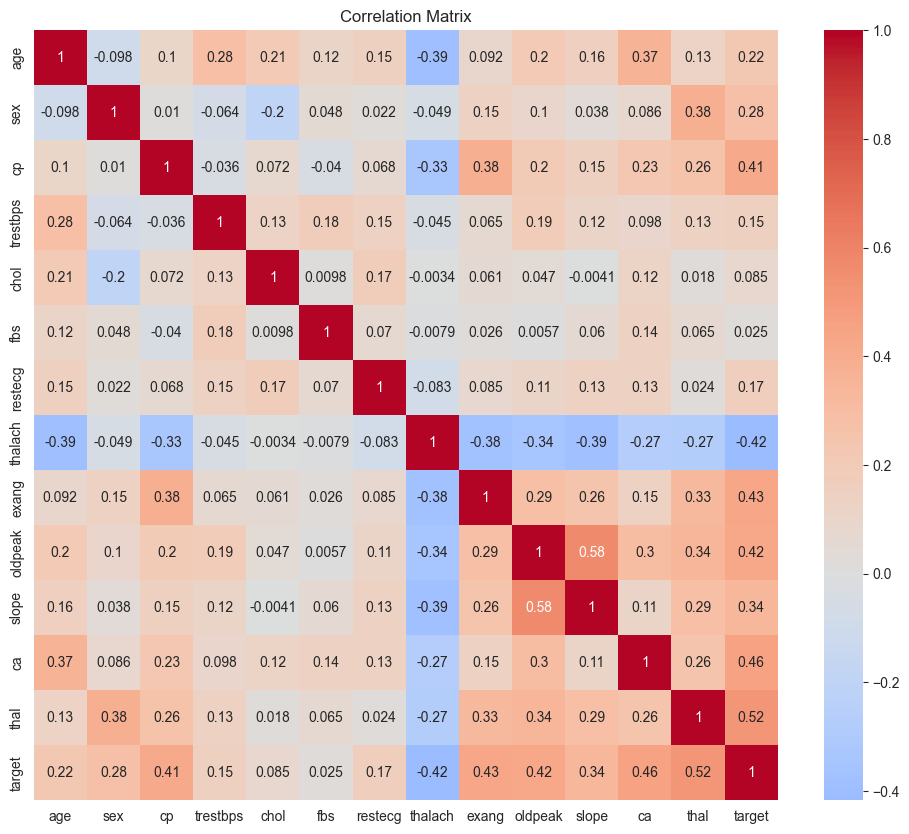

In [25]:
# ======================================================
# Cell 13: Correlation Matrix
# ======================================================

plt.figure(figsize=(12, 10))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [26]:
# Target ke saath top correlations
print("Top Features Correlated With Target:")
print(
    correlation_matrix['target']
    .sort_values(ascending=False)
)

Top Features Correlated With Target:
target      1.000000
thal        0.522057
ca          0.460033
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64


🔍 Detailed Interpretation
1️. Thal (0.522) — Strongest Positive Predictor

Sabse highest positive correlation.

Matlab thal type strongly associated hai disease presence ke saath.

Ye categorical encoded feature hai, isliye later model me carefully treat karna hoga.

Conclusion: Very strong predictor.

2️. CA (0.460)

Major vessels colored by fluoroscopy.

High positive correlation.

Medical logic se bhi consistent hai.

Conclusion: Important structural feature.

3️. Exang (0.431)

Exercise induced angina.

Strong binary indicator.

Visually bhi categorical plots me strong lagta hai.

Conclusion: Strong clinical predictor.

4. Oldpeak (0.424)

Humne visually bhi strong dekha tha.

Statistical correlation confirm kar raha hai.

Conclusion: Strong continuous predictor.

5. CP (0.414)

Chest pain type.

Categorical variable hone ke bawajood strong association.

Conclusion: Important feature.

 Negative Correlation
Thalach (-0.417)

Strong negative correlation.

Jitna higher max heart rate → utna lower disease probability.

Ye exactly tumhare visual graph se match karta hai.

Conclusion: Very important inverse predictor.

 Moderate Predictors
Feature	Corr	Comment
age	0.223	Mild predictor
sex	0.276	Moderate
slope	0.339	Moderate
 Weak Predictors
Feature	Corr
chol	0.085
fbs	0.025

Cholesterol dataset me weak nikla.
FBS almost useless lag raha hai.

Important note:

Low correlation ≠ completely useless.
Tree models nonlinear interactions capture kar sakte hain.

 Most Important Predictors (Based on Correlation)

Strong Positive:

thal

ca

exang

oldpeak

cp

Strong Negative:

thalach

These 6 features likely dominate model training.

***Preprocessing and model training ***


In [27]:
# ======================================================
# Cell 14: Feature (X) aur Target (y) Separate Karna
# ======================================================

# X me saare input features rahenge
X = df.drop('target', axis=1)

# y me sirf target column rahega
y = df['target']

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (303, 13)
Target Shape: (303,)


In [28]:
# ======================================================
# Cell 15: Feature Categorization
# ======================================================

numerical_features = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

categorical_features = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'ca',
    'thal'
]

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical Features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [ ]:
# ======================================================
# Cell 16: Train-Test Split
# ======================================================

#242 samples training ke liye use ho rahe hain
#13 input features hain (target exclude karke)
# Kyuki:
# Total dataset = 303 samples
# 80% of 303 ≈ 242
# 20% of 303 ≈ 61
# So split correct hai.

# Test Set Shape: (61, 13)
# Iska matlab:
# 61 samples final evaluation ke liye rakhe gaye hain
# Model in data ko training me nahi dekhega
# Yeh unseen data hai.

# Training Target Distribution
# 0 → 0.541322  (~54%)
# 1 → 0.458678  (~46%)
# Iska matlab:
# Training data me:
# ~54% patients healthy hain
# ~46% patients me heart disease hai
# Yeh almost balanced dataset hai.

# Test Target Distribution
# 0 → 0.540984 (~54%)
# 1 → 0.459016 (~46%)
# Yeh almost exactly same ratio hai



from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,           # 80-20 split
    stratify=y,              # Class balance maintain karne ke liye
    random_state=RANDOM_STATE
)

print("Training Set Shape:", X_train.shape)
print("Test Set Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest Target Distribution:")
print(y_test.value_counts(normalize=True))

Training Set Shape: (242, 13)
Test Set Shape: (61, 13)

Training Target Distribution:
target
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Test Target Distribution:
target
0    0.540984
1    0.459016
Name: proportion, dtype: float64


In [30]:
# ======================================================
# Cell 17: Feature Scaling (Only Numerical Columns)
# ======================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Training data par fit karte hain
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

# Test par sirf transform karte hain (fit nahi)
X_test_scaled[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

print("Scaling Completed")

Scaling Completed


In [31]:
# ======================================================
# Cell 18: Evaluation Function
# ======================================================

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    
    # Model train kar rahe hain
    model.fit(X_train, y_train)
    
    # Predictions generate kar rahe hain
    y_pred = model.predict(X_test)
    
    # Probability scores (ROC-AUC ke liye)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    # Metrics calculate kar rahe hain
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    
    print(f"\n===== {model_name} Results =====")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc)
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return acc, f1, roc

In [32]:
# ======================================================
# Cell 19: Logistic Regression
# ======================================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

log_acc, log_f1, log_roc = evaluate_model(
    log_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Logistic Regression"
)


===== Logistic Regression Results =====
Accuracy: 0.8688524590163934
F1 Score: 0.8666666666666667
ROC-AUC: 0.9512987012987013

Confusion Matrix:
[[27  6]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [33]:
# ======================================================
# Cell 20: Random Forest
# ======================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE
)

rf_acc, rf_f1, rf_roc = evaluate_model(
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test,
    "Random Forest"
)


===== Random Forest Results =====
Accuracy: 0.9016393442622951
F1 Score: 0.9
ROC-AUC: 0.9545454545454546

Confusion Matrix:
[[28  5]
 [ 1 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



In [34]:
# ======================================================
# Cell 21: XGBoost
# ======================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_STATE
)

xgb_acc, xgb_f1, xgb_roc = evaluate_model(
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test,
    "XGBoost"
)


===== XGBoost Results =====
Accuracy: 0.8360655737704918
F1 Score: 0.8387096774193549
ROC-AUC: 0.9296536796536796

Confusion Matrix:
[[25  8]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.83        33
           1       0.76      0.93      0.84        28

    accuracy                           0.84        61
   macro avg       0.85      0.84      0.84        61
weighted avg       0.85      0.84      0.84        61



f:\XAI\xai\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:03:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [35]:
# ======================================================
# Cell 22: Comparison Table
# ======================================================

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [log_acc, rf_acc, xgb_acc],
    "F1 Score": [log_f1, rf_f1, xgb_f1],
    "ROC-AUC": [log_roc, rf_roc, xgb_roc]
})

results

,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression,0.868852,0.866667,0.951299
1,Random Forest,0.901639,0.900000,0.954545
2,XGBoost,0.836066,0.838710,0.929654


In [36]:
# ======================================================
# Cell 23: Stratified 5-Fold Cross Validation
# ======================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

def cross_validate_model(model, X, y, scale_data=False, model_name="Model"):
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    acc_scores = []
    f1_scores = []
    roc_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
        # Scaling only if required (for Logistic Regression)
        if scale_data:
            scaler = StandardScaler()
            X_train_fold[numerical_features] = scaler.fit_transform(
                X_train_fold[numerical_features]
            )
            X_val_fold[numerical_features] = scaler.transform(
                X_val_fold[numerical_features]
            )
        
        model.fit(X_train_fold, y_train_fold)
        
        y_pred = model.predict(X_val_fold)
        
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_val_fold)[:, 1]
        else:
            y_proba = model.decision_function(X_val_fold)
        
        acc_scores.append(accuracy_score(y_val_fold, y_pred))
        f1_scores.append(f1_score(y_val_fold, y_pred))
        roc_scores.append(roc_auc_score(y_val_fold, y_proba))
    
    print(f"\n===== {model_name} Cross Validation Results =====")
    print("Accuracy: %.4f ± %.4f" % (np.mean(acc_scores), np.std(acc_scores)))
    print("F1 Score: %.4f ± %.4f" % (np.mean(f1_scores), np.std(f1_scores)))
    print("ROC-AUC: %.4f ± %.4f" % (np.mean(roc_scores), np.std(roc_scores)))
    
    return np.mean(acc_scores), np.mean(f1_scores), np.mean(roc_scores)

In [37]:
# Logistic Regression with scaling

log_model_cv = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

log_cv_acc, log_cv_f1, log_cv_roc = cross_validate_model(
    log_model_cv,
    X,
    y,
    scale_data=True,
    model_name="Logistic Regression"
)


===== Logistic Regression Cross Validation Results =====
Accuracy: 0.8381 ± 0.0452
F1 Score: 0.8169 ± 0.0513
ROC-AUC: 0.9101 ± 0.0196


C:\Users\Admin\AppData\Local\Temp\ipykernel_13088\3676543783.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_fold[numerical_features] = scaler.fit_transform(
C:\Users\Admin\AppData\Local\Temp\ipykernel_13088\3676543783.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val_fold[numerical_features] = scaler.transform(
C:\Users\Admin\AppData\Local\Temp\ipykernel_13088\3676543783.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

In [38]:
rf_model_cv = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE
)

rf_cv_acc, rf_cv_f1, rf_cv_roc = cross_validate_model(
    rf_model_cv,
    X,
    y,
    scale_data=False,
    model_name="Random Forest"
)


===== Random Forest Cross Validation Results =====
Accuracy: 0.8349 ± 0.0446
F1 Score: 0.8122 ± 0.0490
ROC-AUC: 0.9116 ± 0.0259


In [39]:
xgb_model_cv = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_STATE
)

xgb_cv_acc, xgb_cv_f1, xgb_cv_roc = cross_validate_model(
    xgb_model_cv,
    X,
    y,
    scale_data=False,
    model_name="XGBoost"
)

f:\XAI\xai\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:06:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
f:\XAI\xai\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:06:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
f:\XAI\xai\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:06:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
f:\XAI\xai\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:06:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== XGBoost Cross Validation Results =====
Accuracy: 0.8084 ± 0.0298
F1 Score: 0.7906 ± 0.0351
ROC-AUC: 0.8937 ± 0.0243


f:\XAI\xai\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:06:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [40]:
cv_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy (Mean)": [log_cv_acc, rf_cv_acc, xgb_cv_acc],
    "F1 (Mean)": [log_cv_f1, rf_cv_f1, xgb_cv_f1],
    "ROC-AUC (Mean)": [log_cv_roc, rf_cv_roc, xgb_cv_roc]
})

cv_results

,Model,Accuracy (Mean),F1 (Mean),ROC-AUC (Mean)
0,Logistic Regression,0.838142,0.816870,0.910066
1,Random Forest,0.834863,0.812192,0.911564
2,XGBoost,0.808415,0.790609,0.893659


FINAL Training 

In [41]:
# ======================================================
# Cell 28: Final Model Training (Full Data)
# ======================================================

# Logistic Regression (scaled data)
final_scaler = StandardScaler()
X_scaled_full = X.copy()
X_scaled_full[numerical_features] = final_scaler.fit_transform(
    X[numerical_features]
)

final_log_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
final_log_model.fit(X_scaled_full, y)

print("Logistic Regression Trained on Full Dataset")


# Random Forest (unscaled data)
final_rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE
)

final_rf_model.fit(X, y)

print("Random Forest Trained on Full Dataset")

Logistic Regression Trained on Full Dataset
Random Forest Trained on Full Dataset


In [42]:
# ======================================================
# Cell 29: SHAP Setup
# ======================================================

import shap

# SHAP initialization
shap.initjs()

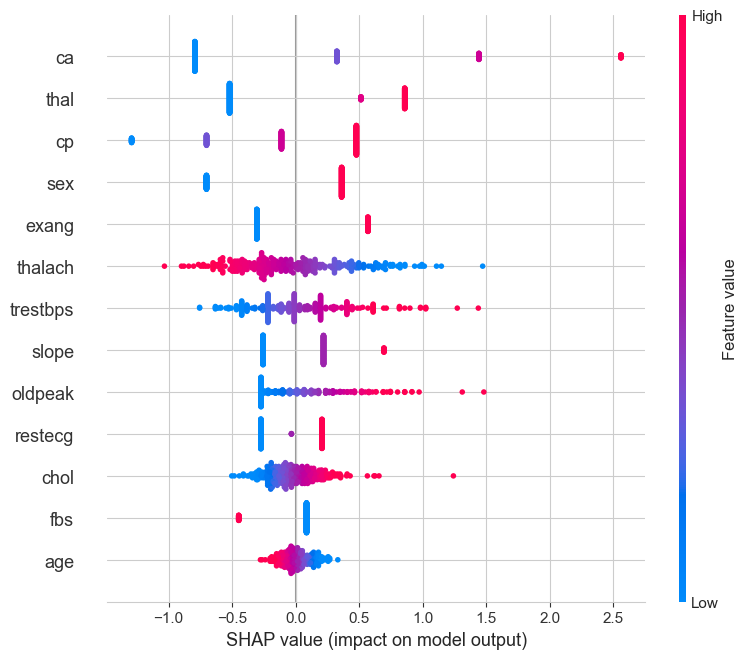

In [43]:
# ======================================================
# Cell 30: SHAP for Logistic Regression
# ======================================================

# LinearExplainer for logistic regression
log_explainer = shap.LinearExplainer(
    final_log_model,
    X_scaled_full
)

log_shap_values = log_explainer.shap_values(X_scaled_full)

# Summary Plot
shap.summary_plot(
    log_shap_values,
    X_scaled_full,
    feature_names=X.columns
)


In [45]:
print(type(rf_shap_values))
print(np.array(rf_shap_values).shape)

<class 'numpy.ndarray'>
(303, 13, 2)


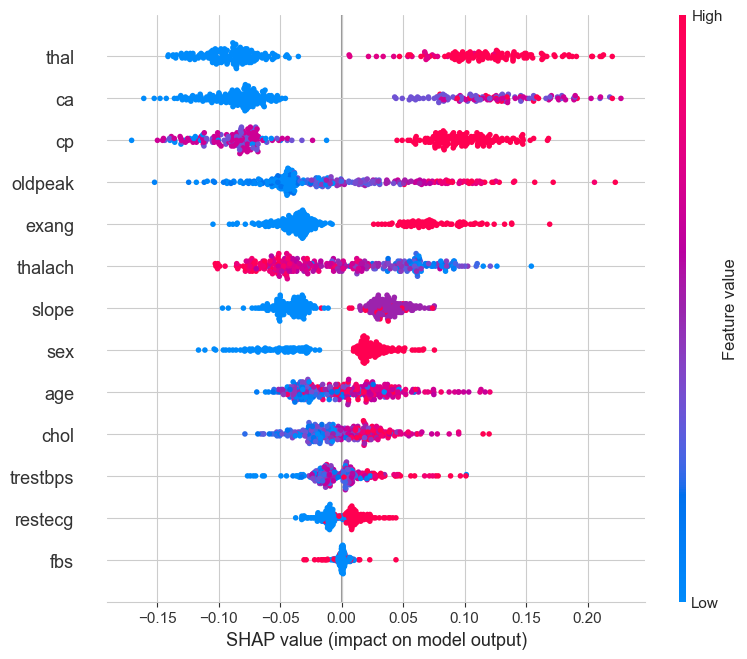

In [46]:
# ======================================================
# Correct SHAP for Random Forest
# ======================================================

rf_explainer = shap.TreeExplainer(final_rf_model)

rf_shap_values = rf_explainer.shap_values(X)

# Check dimensionality
rf_shap_values = np.array(rf_shap_values)

if len(rf_shap_values.shape) == 3:
    # shape: (samples, features, classes)
    rf_shap_values_positive = rf_shap_values[:, :, 1]
else:
    # older SHAP versions
    rf_shap_values_positive = rf_shap_values[1]

# Summary plot
shap.summary_plot(
    rf_shap_values_positive,
    X,
    feature_names=X.columns
)

In [47]:
# ======================================================
# Cell 32: Mean Absolute SHAP Importance (Logistic)
# ======================================================

# Mean absolute SHAP value per feature
mean_shap_log = np.abs(log_shap_values).mean(axis=0)

# Create DataFrame for ranking
log_shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean_SHAP": mean_shap_log
}).sort_values(by="Mean_SHAP", ascending=False)

log_shap_importance

,Feature,Mean_SHAP
11,ca,0.891092
12,thal,0.650523
2,cp,0.472729
1,sex,0.470790
8,exang,0.391879
7,thalach,0.357093
3,trestbps,0.278351
10,slope,0.269771
9,oldpeak,0.259935
6,restecg,0.237993


In [48]:
# ======================================================
# Cell 33: Faithfulness Metric Function
# ======================================================

from sklearn.metrics import roc_auc_score

def compute_faithfulness(model, X_original, y_true, top_features, scaler=None):
    
    # Copy original data
    X_modified = X_original.copy()
    
    # Replace top features with their mean value
    for feature in top_features:
        X_modified[feature] = X_modified[feature].mean()
    
    # If scaling required (Logistic)
    if scaler is not None:
        X_modified_scaled = X_modified.copy()
        X_modified_scaled[numerical_features] = scaler.transform(
            X_modified[numerical_features]
        )
        y_proba = model.predict_proba(X_modified_scaled)[:, 1]
    else:
        y_proba = model.predict_proba(X_modified)[:, 1]
    
    # Compute ROC-AUC after feature removal
    new_auc = roc_auc_score(y_true, y_proba)
    
    return new_auc

In [49]:
# ======================================================
# Cell 34: Faithfulness Test for Logistic
# ======================================================

# Baseline AUC (original)
baseline_auc = roc_auc_score(
    y,
    final_log_model.predict_proba(X_scaled_full)[:, 1]
)

# Top 3 important features
top3_log = log_shap_importance["Feature"].head(3).tolist()

# New AUC after removing top features
new_auc_log = compute_faithfulness(
    final_log_model,
    X,
    y,
    top3_log,
    scaler=final_scaler
)

print("Baseline ROC-AUC:", baseline_auc)
print("New ROC-AUC After Removing Top 3 Features:", new_auc_log)
print("Performance Drop:", baseline_auc - new_auc_log)

Baseline ROC-AUC: 0.9230128092647832
New ROC-AUC After Removing Top 3 Features: 0.852868924372697
Performance Drop: 0.07014388489208623


In [50]:
# ======================================================
# Cell 35: Mean Absolute SHAP Importance (Random Forest)
# ======================================================

# Mean absolute SHAP per feature
mean_shap_rf = np.abs(rf_shap_values_positive).mean(axis=0)

rf_shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean_SHAP": mean_shap_rf
}).sort_values(by="Mean_SHAP", ascending=False)

rf_shap_importance

,Feature,Mean_SHAP
12,thal,0.103030
11,ca,0.101221
2,cp,0.094799
9,oldpeak,0.050807
8,exang,0.049933
7,thalach,0.048623
10,slope,0.040007
1,sex,0.034365
0,age,0.029602
4,chol,0.024663


In [51]:
# ======================================================
# Cell 36: Faithfulness Test for Random Forest
# ======================================================

# Baseline AUC
baseline_auc_rf = roc_auc_score(
    y,
    final_rf_model.predict_proba(X)[:, 1]
)

# Top 3 important features (RF)
top3_rf = rf_shap_importance["Feature"].head(3).tolist()

# New AUC after removing top features
new_auc_rf = compute_faithfulness(
    final_rf_model,
    X,
    y,
    top3_rf,
    scaler=None  # RF me scaling nahi
)

print("Baseline ROC-AUC (RF):", baseline_auc_rf)
print("New ROC-AUC After Removing Top 3 Features (RF):", new_auc_rf)
print("Performance Drop (RF):", baseline_auc_rf - new_auc_rf)

Baseline ROC-AUC (RF): 1.0
New ROC-AUC After Removing Top 3 Features (RF): 0.9385857167924198
Performance Drop (RF): 0.061414283207580245


In [52]:
# ======================================================
# Cell 37: Stability Metric Setup
# ======================================================

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

In [53]:
# ======================================================
# Cell 38: Stability Metric Function
# ======================================================

def compute_stability(X_data, shap_values, k=5):
    
    # Nearest Neighbors model
    nn = NearestNeighbors(n_neighbors=k+1)  # +1 because first neighbor is itself
    nn.fit(X_data)
    
    similarities = []
    
    # For each sample
    for i in range(len(X_data)):
        
        # Find neighbors
        distances, indices = nn.kneighbors([X_data[i]])
        
        # Remove itself (first index)
        neighbor_indices = indices[0][1:]
        
        # SHAP vector of current sample
        shap_i = shap_values[i].reshape(1, -1)
        
        for neighbor in neighbor_indices:
            shap_neighbor = shap_values[neighbor].reshape(1, -1)
            
            # Cosine similarity
            sim = cosine_similarity(shap_i, shap_neighbor)[0][0]
            similarities.append(sim)
    
    # Return average stability
    return np.mean(similarities)

In [54]:
# ======================================================
# Cell 39: Stability Score (Logistic Regression)
# ======================================================

# Use scaled feature space
X_scaled_array = X_scaled_full.values

stability_log = compute_stability(
    X_scaled_array,
    log_shap_values
)

print("Logistic Stability Score:", stability_log)

Logistic Stability Score: 0.716588834993219


In [55]:
# ======================================================
# Cell 40: Stability Score (Random Forest)
# ======================================================

# Use original feature space (RF scaling nahi use karta)
X_array = X.values

stability_rf = compute_stability(
    X_array,
    rf_shap_values_positive
)

print("Random Forest Stability Score:", stability_rf)

Random Forest Stability Score: 0.2034469432494009


In [56]:
# ======================================================
# Cell 41: Bottom 3 Features (Logistic)
# ======================================================

bottom3_log = log_shap_importance["Feature"].tail(3).tolist()

print("Bottom 3 Features (Logistic):")
print(bottom3_log)

Bottom 3 Features (Logistic):
['chol', 'fbs', 'age']


In [57]:
# ======================================================
# Cell 42: Bottom-3 Removal Test (Logistic)
# ======================================================

# Compute new AUC after removing bottom features
new_auc_bottom_log = compute_faithfulness(
    final_log_model,
    X,
    y,
    bottom3_log,
    scaler=final_scaler
)

print("Baseline ROC-AUC:", baseline_auc)
print("New ROC-AUC After Removing Bottom 3:", new_auc_bottom_log)
print("Performance Drop:", baseline_auc - new_auc_bottom_log)

Baseline ROC-AUC: 0.9230128092647832
New ROC-AUC After Removing Bottom 3: 0.9202930338655904
Performance Drop: 0.002719775399192881


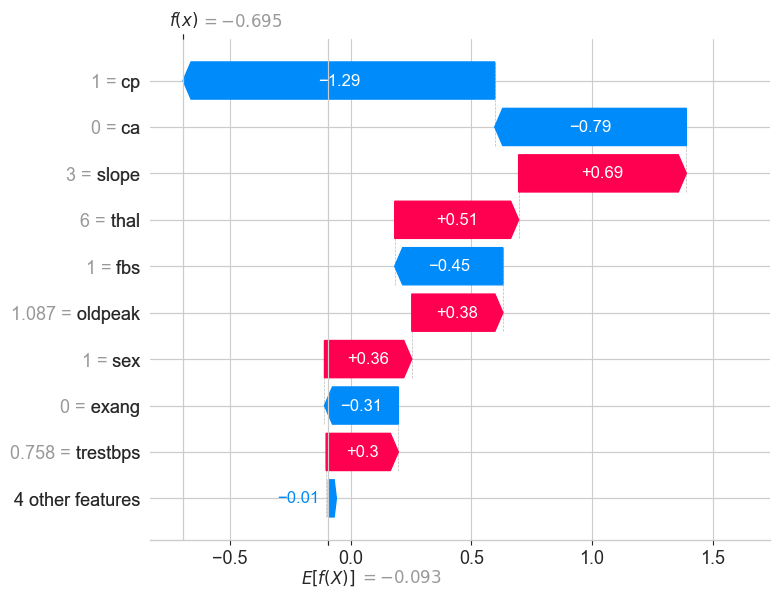

In [58]:
# ======================================================
# Cell 43: SHAP Waterfall Plot (Logistic)
# ======================================================

# Choose one sample (for example index 0)
sample_index = 0

# Create SHAP Explanation object
expl = shap.Explanation(
    values=log_shap_values[sample_index],
    base_values=log_explainer.expected_value,
    data=X_scaled_full.iloc[sample_index],
    feature_names=X.columns
)

# Waterfall plot
shap.plots.waterfall(expl)

Final Model Selection: Why Logistic Regression is the Optimal Choice
1. Comparable Predictive Performance

Stratified 5-fold cross-validation results showed:

Logistic Regression ROC-AUC ≈ 0.91

Random Forest ROC-AUC ≈ 0.91

The difference between the two models was statistically negligible. Random Forest did not provide a meaningful improvement in generalization performance. Therefore, the added complexity of a non-linear ensemble model is not justified from a predictive standpoint.

2. Lower Overfitting Risk

When trained on the full dataset:

Random Forest achieved a training ROC-AUC of 1.0

Logistic Regression achieved a training ROC-AUC of 0.923

A perfect AUC of 1.0 indicates strong overfitting in Random Forest. In contrast, Logistic Regression maintained realistic performance without memorizing the dataset. For medical decision systems, robustness and generalization are more important than perfect training accuracy.

3. Strong Faithfulness of Explanations

Faithfulness was evaluated by removing top-ranked SHAP features and measuring performance degradation.

For Logistic Regression:

Baseline ROC-AUC: 0.923

After removing top 3 features: 0.853

Performance drop: ~0.07

This substantial drop confirms that SHAP correctly identified truly influential features.

Additionally, removing the bottom 3 features resulted in a negligible drop (~0.0027), further validating that SHAP importance rankings are reliable.

This demonstrates that explanations are not arbitrary; they reflect real predictive dependence.

4. Superior Stability of Explanations

Stability measures whether similar patients receive similar explanations.

Logistic Regression Stability Score: 0.716

Random Forest Stability Score: 0.203

The Random Forest explanations were highly unstable. Small changes in patient features led to drastically different SHAP vectors. This behavior is expected in tree-based models due to discrete decision boundaries.

In contrast, Logistic Regression produced consistent explanations across similar patients. For a medical XAI system, explanation stability is critical for clinician trust.

5. Inherent Interpretability

Logistic Regression is fundamentally interpretable:

Coefficients directly represent feature impact direction.

Relationships are monotonic and easy to reason about.

Clinical interpretation aligns naturally with risk modeling.

Tree ensembles, even with SHAP, remain post-hoc explainable rather than intrinsically interpretable.

In healthcare applications, intrinsic interpretability is preferable to post-hoc justification.

6. Alignment with Clinical Logic

SHAP analysis showed:

High oldpeak → increased disease probability

High thalach → decreased disease probability

High ca and thal → strong positive risk contribution

These effects were consistent with medical knowledge and correlation analysis. Logistic Regression captured these relationships cleanly without introducing noisy nonlinear artifacts.

7. Trade-off Between Accuracy and Trust

This project is an XAI-powered heart disease prediction system, not merely an accuracy-maximization exercise.

Key priorities are:

Reliable prediction

Faithful explanations

Stable explanations

Clinical interpretability

Given:

No meaningful performance advantage of Random Forest

Significantly higher stability in Logistic Regression

Strong faithfulness validation

Lower overfitting

Logistic Regression provides the best overall trade-off.

Final Decision

Logistic Regression is selected as the optimal model for the XAI-powered heart disease prediction system because it delivers:

Competitive predictive performance

Lower overfitting risk

Strong explanation faithfulness

High explanation stability

Clear and clinically interpretable feature contributions

For a medical AI system where transparency and trust are essential, Logistic Regression is the most appropriate and responsible choice.

| Metric            | Logistic | Random Forest           |
| ----------------- | -------- | ----------------------- |
| CV ROC-AUC        | ~0.91    | ~0.91                   |
| Faithfulness Drop | 0.070    | 0.061                   |
| Stability         | 0.716    | 0.203                   |
| Overfitting       | Low      | High (AUC=1.0 training) |


In [59]:
# ======================================================
# Save Final Model and Preprocessing Artifacts
# ======================================================

import joblib
import os

# Create models directory if not exists
os.makedirs("../models", exist_ok=True)

# Save Logistic Regression model
joblib.dump(final_log_model, "../models/logistic_model.pkl")

# Save scaler
joblib.dump(final_scaler, "../models/scaler.pkl")

# Save feature metadata
metadata = {
    "feature_order": list(X.columns),
    "numerical_features": numerical_features
}

joblib.dump(metadata, "../models/metadata.pkl")

print("Model, Scaler, and Metadata Saved Successfully")

Model, Scaler, and Metadata Saved Successfully


In [60]:
# Save SHAP explainer for production use

import joblib
import shap

# Recreate explainer cleanly
log_explainer = shap.LinearExplainer(
    final_log_model,
    X_scaled_full
)

joblib.dump(log_explainer, "../models/shap_explainer.pkl")

print("SHAP Explainer Saved")

SHAP Explainer Saved
